# What we're covering in the Scikit-Learn Introduction

This notebook outlines the content convered in the Scikit-Learn Introduction.

It's a quick stop to see all the Scikit-Learn functions and modules for each section outlined.

What we're covering follows the following diagram detailing a Scikit-Learn workflow.

<img src="../images/sklearn-workflow-title.png"/>

## 0. Standard library imports

For all machine learning projects, you'll often see these libraries (Matplotlib, NumPy and pandas) imported at the top.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

We'll use 2 datasets for demonstration purposes.
* `heart_disease` - a classification dataset (predicting whether someone has heart disease or not)
* `boston_df` - a regression dataset (predicting the median house prices of cities in Boston)

In [2]:
# Classification data
heart_disease = pd.read_csv("./sample_project/heart-disease.csv")

# # Regression data
# from sklearn.datasets import load_boston
# boston = load_boston() # loads as dictionary
# # Convert dictionary to dataframe
# boston_df = pd.DataFrame(boston["data"], columns=boston["feature_names"])
# boston_df["target"] = pd.Series(boston["target"])

url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
boston_df = pd.read_csv(url)
boston_df.rename(columns={"medv": "target"}, inplace=True)

## 1. Get the data ready

In [3]:
# Split data into X & y
X = heart_disease.drop("target", axis=1) # use all columns except target
y = heart_disease["target"] # we want to predict y using X

In [4]:
# Split the data into training and test sets
from sklearn.model_selection import train_test_split
# Example use case (requires X & y)
X_train, X_test, y_train, y_test = train_test_split(X, y)

## 2. Pick a model/estimator (to suit your problem)
To pick a model we use the [Scikit-Learn machine learning map](https://scikit-learn.org/stable/tutorial/machine_learning_map/index.html).

<img src="../images/sklearn-ml-map.png" width=400/>

**Note:** Scikit-Learn refers to machine learning models and algorithms as estimators.

In [5]:
# Random Forest Classifier (for classification problems)
from sklearn.ensemble import RandomForestClassifier
# Instantiating a Random Forest Classifier (clf short for classifier)
clf = RandomForestClassifier()

In [6]:
# Random Forest Regressor (for regression problems)
from sklearn.ensemble import RandomForestRegressor
# Instantiating a Random Forest Regressor
model = RandomForestRegressor()

## 3. Fit the model to the data and make a prediction


In [7]:
# All models/estimators have the fit() function built-in
clf.fit(X_train, y_train)

# Once fit is called, you can make predictions using predict()
y_preds = clf.predict(X_test)

# You can also predict with probabilities (on classification models)
y_probs = clf.predict_proba(X_test)

# View preds/probabilities
y_preds, y_probs

(array([1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1,
        0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1,
        0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0,
        0, 0, 1, 1, 1, 1, 0, 1, 0, 1]),
 array([[0.08, 0.92],
        [0.04, 0.96],
        [0.14, 0.86],
        [0.42, 0.58],
        [0.72, 0.28],
        [0.92, 0.08],
        [0.07, 0.93],
        [0.29, 0.71],
        [0.03, 0.97],
        [0.12, 0.88],
        [0.07, 0.93],
        [0.03, 0.97],
        [0.  , 1.  ],
        [0.22, 0.78],
        [0.04, 0.96],
        [0.78, 0.22],
        [0.27, 0.73],
        [0.24, 0.76],
        [0.18, 0.82],
        [0.95, 0.05],
        [0.03, 0.97],
        [0.4 , 0.6 ],
        [0.91, 0.09],
        [0.2 , 0.8 ],
        [0.86, 0.14],
        [0.17, 0.83],
        [0.59, 0.41],
        [0.08, 0.92],
        [0.78, 0.22],
        [0.94, 0.06],
        [0.69, 0.31],
        [0.73, 0.27],
        [1.  , 0.  ],
        [0.7

## 4. Evaluate the model

Every Scikit-Learn model has a default metric which is accessible through the `score()` function.

However there are a range of different evaluation metrics you can use depending on the model you're using.

A full list of evaluation metrics can be [found in the documentation](https://scikit-learn.org/stable/modules/model_evaluation.html).

In [8]:
# All models/estimators have a score() function
clf.score(X_test, y_test)

0.7894736842105263

In [9]:
# Evaluting a model using cross-validation is possible with cross_val_score
from sklearn.model_selection import cross_val_score

# scoring=None means default score() metric is used
print(cross_val_score(estimator=clf, 
                      X=X, 
                      y=y, 
                      cv=5, # use 5-fold cross-validation
                      scoring=None)) 

# Evaluate a model with a different scoring method
print(cross_val_score(estimator=clf, 
                      X=X, 
                      y=y,
                      cv=5, # use 5-fold cross-validation
                      scoring="precision"))

[0.83606557 0.8852459  0.80327869 0.83333333 0.71666667]
[0.81818182 0.9375     0.81818182 0.81081081 0.75675676]


In [10]:
# Different classification metrics

# Accuracy
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_preds))

# Reciver Operating Characteristic (ROC curve)/Area under curve (AUC)
from sklearn.metrics import roc_curve, roc_auc_score
false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_probs[:, 1])
print(roc_auc_score(y_test, y_preds))

# Confusion matrix
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_preds))

# Classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_preds))

0.7894736842105263
0.7894736842105263
[[26 12]
 [ 4 34]]
              precision    recall  f1-score   support

           0       0.87      0.68      0.76        38
           1       0.74      0.89      0.81        38

    accuracy                           0.79        76
   macro avg       0.80      0.79      0.79        76
weighted avg       0.80      0.79      0.79        76



In [11]:
# Different regression metrics

# Make predictions first
X = boston_df.drop("target", axis=1)
y = boston_df["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestRegressor()
model.fit(X_train, y_train)
y_preds = model.predict(X_test)

# R^2 (pronounced r-squared) or coefficient of determination
from sklearn.metrics import r2_score
print(r2_score(y_test, y_preds))

# Mean absolute error (MAE)
from sklearn.metrics import mean_absolute_error
print(mean_absolute_error(y_test, y_preds))

# Mean square error (MSE)
from sklearn.metrics import mean_squared_error
print(mean_squared_error(y_test, y_preds))

0.8747106333874244
2.127499999999999
10.523440343137265


## 5. Improve through experimentation

Two of the main methods to improve a models baseline metrics (the first evaluation metrics you get).

From a data perspective asks:
* Could we collect more data? In machine learning, more data is generally better, as it gives a model more opportunities to learn patterns.
* Could we improve our data? This could mean filling in misisng values or finding a better encoding (turning things into numbers) strategy.

From a model perspective asks:
* Is there a better model we could use? If you've started out with a simple model, could you use a more complex one? (we saw an example of this when looking at the [Scikit-Learn machine learning map](https://scikit-learn.org/stable/tutorial/machine_learning_map/index.html), ensemble methods are generally considered more complex models)
* Could we improve the current model? If the model you're using performs well straight out of the box, can the **hyperparameters** be tuned to make it even better?

**Hyperparameters** are like settings on a model you can adjust so some of the ways it uses to find patterns are altered and potentially improved. Adjusting hyperparameters is referred to as hyperparameter tuning.

In [12]:
# How to find a model's hyperparameters
clf = RandomForestClassifier()
clf.get_params() # returns a list of adjustable hyperparameters

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [13]:
# Example of adjusting hyperparameters by hand

# Split data into X & y
X = heart_disease.drop("target", axis=1) # use all columns except target
y = heart_disease["target"] # we want to predict y using X

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y)

# Instantiate two models with different settings
clf_1 = RandomForestClassifier(n_estimators=100)
clf_2 = RandomForestClassifier(n_estimators=200)

# Fit both models on training data
clf_1.fit(X_train, y_train)
clf_2.fit(X_train, y_train)

# Evaluate both models on test data and see which is best
print(clf_1.score(X_test, y_test))
print(clf_2.score(X_test, y_test))

0.8289473684210527
0.8289473684210527


In [14]:
# Example of adjusting hyperparameters computationally (recommended)

from sklearn.model_selection import RandomizedSearchCV

# Define a grid of hyperparameters
grid = {"n_estimators": [10, 100, 200, 500, 1000, 1200],
        "max_depth": [None, 5, 10, 20, 30],
        "max_features": ["auto", "sqrt"],
        "min_samples_split": [2, 4, 6],
        "min_samples_leaf": [1, 2, 4]}

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Set n_jobs to -1 to use all cores (NOTE: n_jobs=-1 is broken as of 8 Dec 2019, using n_jobs=1 works)
clf = RandomForestClassifier(n_jobs=1)

# Setup RandomizedSearchCV
rs_clf = RandomizedSearchCV(estimator=clf,
                            param_distributions=grid,
                            n_iter=10, # try 10 models total
                            cv=5, # 5-fold cross-validation
                            verbose=2) # print out results

# Fit the RandomizedSearchCV version of clf
rs_clf.fit(X_train, y_train);

# Find the best hyperparameters
print(rs_clf.best_params_)

# Scoring automatically uses the best hyperparameters
rs_clf.score(X_test, y_test)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END max_depth=None, max_features=auto, min_samples_leaf=4, min_samples_split=4, n_estimators=1200; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=4, min_samples_split=4, n_estimators=1200; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=4, min_samples_split=4, n_estimators=1200; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=4, min_samples_split=4, n_estimators=1200; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=4, min_samples_split=4, n_estimators=1200; total time=   0.0s
[CV] END max_depth=20, max_features=auto, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END max_depth=20, max_features=auto, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END max_depth=20, max_features=auto, min_samples_leaf=2, min_samples_split=2, n

/Users/MarkCalvelo/Desktop/Udemy/complete_MLDataScience_bootcamp/sample_project/env/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
35 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
35 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/MarkCalvelo/Desktop/Udemy/complete_MLDataScience_bootcamp/sample_project/env/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/MarkCalvelo/Desktop/Udemy/complete_MLDataScience_bootcamp/sample_project/env/lib/python3.13/site-packages

{'n_estimators': 1200, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}


0.8032786885245902

## 6. Save and reload your trained model
You can save and load a model with `pickle`.

In [15]:
# Saving a model with pickle
import pickle

# Save an existing model to file
pickle.dump(rs_clf, open("rs_random_forest_model_1.pkl", "wb"))

In [16]:
# Load a saved pickle model
loaded_pickle_model = pickle.load(open("rs_random_forest_model_1.pkl", "rb"))

# Evaluate loaded model
loaded_pickle_model.score(X_test, y_test)

0.8032786885245902

You can do the same with `joblib`. `joblib` is usually more efficient with numerical data (what our models are).

In [17]:
# Saving a model with joblib
from joblib import dump, load

# Save a model to file
dump(rs_clf, filename="gs_random_forest_model_1.joblib") 

['gs_random_forest_model_1.joblib']

In [18]:
# Import a saved joblib model
loaded_joblib_model = load(filename="gs_random_forest_model_1.joblib")

In [19]:
# Evaluate joblib predictions 
loaded_joblib_model.score(X_test, y_test)

0.8032786885245902

## 7. Putting it all together (not pictured)

We can put a number of different Scikit-Learn functions together using `Pipeline`.

As an example, we'll use `car-sales-extended-missing-data.csv`. Which has missing data as well as non-numeric data. For a machine learning model to work, there can be no missing data or non-numeric values.

The problem we're solving here is predicting a cars sales price given a number of parameters about the car (a regression problem).

In [40]:
# Getting data ready
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Modelling
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV

# Setup random seed
import numpy as np
np.random.seed(42)

# Import data and drop the rows with missing labels
data = pd.read_csv("sample_project/data/car-sales-extended-missing-data.csv")
data.dropna(subset=["Price"], inplace=True)

# Define different features and transformer pipelines
categorical_features = ["Make", "Colour"]
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))])

door_feature = ["Doors"]
door_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value=4))])

numeric_features = ["Odometer (KM)"]
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean"))
])

# Setup preprocessing steps (fill missing values, then convert to numbers)
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_features),
        ("door", door_transformer, door_feature),
        ("num", numeric_transformer, numeric_features)])

# Create a preprocessing and modelling pipeline
model = Pipeline(steps=[("preprocessor", preprocessor),
                        ("model", RandomForestRegressor())])

# Split data
X = data.drop("Price", axis=1)
y = data["Price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Fit and score the model
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.22188417408787875

## 2. Choosing the right estimator/algorithm for your problem

Some things to note:

* Sklearn refers to machine learning models, algorithms as estimators.
* Classification problem - predicting a category (heart disease or not)
      * Sometimes you'll see "clf" (short for classifier) used as a classification estimator
* Regressiont problem - predicting a number (selling price of a car)

If you are working on a machine learning proble mand are looking to use Sklearn and not sure what model you should use, refer to the [Sklearn machine learning map](https://scikit-learn.org/stable/machine_learning_map.html)

### 2.1 Picking a machine learning model for a regression problem

Let us use the California Housing Dataset.

In [41]:
# Get California Housing dataset
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [42]:
housing_df = pd.DataFrame(housing["data"], columns=housing["feature_names"])
housing_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [43]:
housing_df["MedHouseVal"] = housing["target"]
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [44]:
housing_df["target"] = housing["target"]
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,3.422


In [45]:
housing_df = housing_df.drop("MedHouseVal", axis=1)

In [46]:
housing_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [47]:
# Import algorithm
from sklearn.linear_model import Ridge

# Setup random seed
np.random.seed(42)

# Create the data
X = housing_df.drop("target", axis=1)
y = housing_df["target"] # median house price in $100,000s

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Instantiate and fit the estimator (on the training set)
model = Ridge()
model.fit(X_train, y_train)

# Check the score of the model (on the test set)
model.score(X_test, y_test)

0.5758549611440127

What if Ridge didn't work or the score did not fit our needs?

Well, we can always try a different model.

How about we try an ensemble model? (An ensemble is a combination of smaller models to try to make better predictions than just a single model)

Sklearn's Ensemble models [scikit-learn.org/stable/auto_examples/ensemble/index](https://scikit-learn.org/stable/auto_examples/ensemble/index.html)

In [48]:
# Import the RandomForestRegressor model class from the ensemble module
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Setup random seed
np.random.seed(42)

# Create the data
X = housing_df.drop("target", axis=1)
y = housing_df["target"]

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Create random forest model
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Check the score of the model (on the test set)
model.score(X_test, y_test)

0.8066196804802649

## 2.2 Picking a machine learning model for a classification model

In [49]:
heart_disease = pd.read_csv("./sample_project/heart-disease.csv")
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [50]:
len(heart_disease)

303

Consulting the map and it says to try ```LinearSVC```

In [51]:
# Import the LinearSVC estimator class
from sklearn.svm import LinearSVC

# Setup random seed
np.random.seed(42)

# Make the data
X = heart_disease.drop("target", axis=1)
y = heart_disease["target"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Instantiate LinearSVC
clf = LinearSVC()
clf.fit(X_train, y_train)

# Evaluate the LinearSVC
clf.score(X_test, y_test)

0.8688524590163934

In [52]:
# Import the RandomForestClassifier model class from the ensemble module
from sklearn.ensemble import RandomForestClassifier

# Setup random seed
np.random.seed(42)

# Create the data
X = heart_disease.drop("target", axis=1)
y = heart_disease["target"]

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Create random forest model
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

# Check the score of the model (on the test set)
model.score(X_test, y_test)

0.8524590163934426

Tidbit:

    1. If you have structured data, use ensemble methods
    2. If you have unstructured data, use deep learning or transfer learning

## 3 Fit the model/algorithm oon our data and use it to make predictions

### 3.1 Fit the model to the data

Different names for:
* X = features, features variables, data
* y = labels, targets, target variables

In [53]:
# Import the RandomForestClassifier model class from the ensemble module
from sklearn.ensemble import RandomForestClassifier

# Setup random seed
np.random.seed(42)

# Create the data
X = heart_disease.drop("target", axis=1)
y = heart_disease["target"]

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Create random forest model
clf = RandomForestClassifier(n_estimators=100)

# Fit the model to the data (training the machine learning estimator)
clf.fit(X_train, y_train)

# Check the score of the model (on the test set, use the patterns the model has learned)
clf.score(X_test, y_test)

0.8524590163934426

In [54]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


In [55]:
y.tail()

298    0
299    0
300    0
301    0
302    0
Name: target, dtype: int64

### 3.2 Make predictions using a machine learning model

2 wways to make predictions:
1. ```predict()```
2. ```predict_proba()```

In [56]:
# Use a trained model to make predictions
# clf.predict(np.array([1, 7, 8, 3, 4])) # this does not work....

In [57]:
X_test

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
179,57,1,0,150,276,0,0,112,1,0.6,1,1,1
228,59,1,3,170,288,0,0,159,0,0.2,1,0,3
111,57,1,2,150,126,1,1,173,0,0.2,2,1,3
246,56,0,0,134,409,0,0,150,1,1.9,1,2,3
60,71,0,2,110,265,1,0,130,0,0.0,2,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
249,69,1,2,140,254,0,0,146,0,2.0,1,3,3
104,50,1,2,129,196,0,1,163,0,0.0,2,0,2
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
193,60,1,0,145,282,0,0,142,1,2.8,1,2,3


In [58]:
clf.predict(X_test) # predictions are in the same format as our test labels

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [59]:
y_test

179    0
228    0
111    1
246    0
60     1
      ..
249    0
104    1
300    0
193    0
184    0
Name: target, Length: 61, dtype: int64

In [60]:
np.array(y_test)

array([0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [61]:
# Compare predictions to truth labels (ground truth) to evaluate the model
y_preds = clf.predict(X_test)
np.mean(y_preds == y_test)

np.float64(0.8524590163934426)

In [62]:
clf.score(X_test, y_test) # calculating the accuracy versus ground truth

0.8524590163934426

In [63]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_preds)

0.8524590163934426

Make predictions with ```predict_proba()```

In [64]:
# predict_proba() returns probabilities of a classification label
clf.predict_proba(X_test[:5])

array([[0.89, 0.11],
       [0.49, 0.51],
       [0.43, 0.57],
       [0.84, 0.16],
       [0.18, 0.82]])

In [65]:
# Let's predict() on the same data...
clf.predict(X_test[:5])

array([0, 1, 1, 0, 1])

In [66]:
heart_disease["target"].value_counts

<bound method IndexOpsMixin.value_counts of 0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64>

```predict()``` can also be used for regression models.

In [67]:
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [68]:
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)

# Create the data
X = housing_df.drop("target", axis=1)
y = housing_df["target"]

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Create estimator instance
model = RandomForestRegressor(n_estimators=100)

# Fit the model to the data
model.fit(X_train, y_train) # training features, training labels

# Make predictions
y_preds = model.predict(X_test)

In [69]:
y_preds[:10]

array([0.49384  , 0.75494  , 4.9285964, 2.54029  , 2.33176  , 1.6549701,
       2.34323  , 1.66182  , 2.47489  , 4.8344779])

In [70]:
np.array(y_test[:10])

array([0.477  , 0.458  , 5.00001, 2.186  , 2.78   , 1.587  , 1.982  ,
       1.575  , 3.4    , 4.466  ])

In [71]:
# Compare the predictions to the truth
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test, y_preds)

0.3265721842781009

In [72]:
housing_df["target"] 

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: target, Length: 20640, dtype: float64

## 4. Evaluating a machine learning model

Three ways to evaluate Scikit-Learn model/estimators:
1. Estimator's built-in ```score()``` method
2. the scoring parameter
3. Problem specific metric functions

You can read more about these in the [Scikit-Learn model evaluation documentation](https://scikit-learn.org/0.15/modules/model_evaluation.html)

#### Evaluating a model with the ```score``` method

In [73]:
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

# Create the data
X = heart_disease.drop("target", axis=1)
y = heart_disease["target"]

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Create estimator instance
model = RandomForestClassifier(n_estimators=100)

# Fit the model to the data
model.fit(X_train, y_train) # training features, training labels

# Make predictions
y_preds = model.predict(X_test)

In [74]:
# The highest value for the score() method is 1.0, lowest 0.0
model.score(X_train, y_train)

1.0

In [75]:
# The highest value for the score() method is 1.0, lowest 0.0
model.score(X_test, y_test)

0.8524590163934426

Let's use the ```score()``` on our regression problem...

In [76]:
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)

# Create the data
X = housing_df.drop("target", axis=1)
y = housing_df["target"]

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Create estimator instance
model = RandomForestRegressor(n_estimators=1000, n_jobs=-1)

# Fit the model to the data
model.fit(X_train, y_train) # training features, training labels

# Make predictions
y_preds = model.predict(X_test)

In [77]:
# score the model on training data

model.score(X_train, y_train)

0.9746611063398356

In [78]:
# The default score() evaluation metric is r_squared for regression algorithms
# Highest = 1.0, lowest = 0.0

model.score(X_test, y_test)

0.8083290150437414

In [79]:
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [80]:
y_test.mean()

np.float64(2.0550030959302323)

### 4.2 Evaluating a model using the ```scoring``` parameter

In [81]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

# Create the data
X = heart_disease.drop("target", axis=1)
y = heart_disease["target"]

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Create estimator instance
model = RandomForestClassifier(n_estimators=100)

# Fit the model to the data
model.fit(X_train, y_train) # training features, training labels

model.score(X_test, y_test)

0.8524590163934426

In [82]:
cross_val_score(model, X, y, cv=5)

array([0.81967213, 0.86885246, 0.81967213, 0.78333333, 0.76666667])

In [83]:
cross_val_score(model, X, y, cv=10)

array([0.90322581, 0.80645161, 0.87096774, 0.9       , 0.86666667,
       0.8       , 0.73333333, 0.86666667, 0.73333333, 0.8       ])

In [84]:
np.random.seed(42)

# Single training and test split score
clf_single_score = model.score(X_test, y_test)

# Pass the mean of 5-fold cross-validation score
clf_cross_val_score = np.mean(cross_val_score(model, X, y, cv=5))

# Compare the two
clf_single_score, clf_cross_val_score

(0.8524590163934426, np.float64(0.8248087431693989))

In [85]:
# Default scoring parameter of classifer = mean accuracy
# Scoring parameter set to none by default
cross_val_score(model, X, y, cv=5, scoring=None)

array([0.78688525, 0.86885246, 0.80327869, 0.78333333, 0.76666667])

### 4.2.1 Classification model evaluation metrics

1. Accuracy
2. Area under ROC curve
3. Confusion matrix
4. Classification report

In [86]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

X = heart_disease.drop("target", axis=1)
y = heart_disease["target"]

clf = RandomForestClassifier(n_estimators=100)
our_cross_val_score = cross_val_score(clf, X, y, cv=5)

In [87]:
np.mean(our_cross_val_score)

np.float64(0.8248087431693989)

In [88]:
print(f"Heart Disease Classfier Cross-Validated Accuracy: {np.mean(our_cross_val_score) *100:.2f}%")

Heart Disease Classfier Cross-Validated Accuracy: 82.48%


**Area Under the receiver operating characteristic curve (AUC/ROC)**

* Area under curve (AUC)
* ROC curve

ROC curves are a comparison of a model's true positive rate (tpr) versus a model's false positive rate (fpr).

* True positive = model predicts 1 when truth is 1
* False positive = model predicts 1 when truth is 0
* True negative = model predicts 0 when truth is 0
* False negative = model predicts 0 when truth is 1

In [89]:
# Create X_test...etc
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [91]:
from sklearn.metrics import roc_curve

# Fit the classifier
clf.fit(X_train, y_train)

# Make predictions with probabilities
y_probs = clf.predict_proba(X_test)

y_probs[:10], len(y_probs)

(array([[0.9 , 0.1 ],
        [0.5 , 0.5 ],
        [0.38, 0.62],
        [0.92, 0.08],
        [0.27, 0.73],
        [0.12, 0.88],
        [0.43, 0.57],
        [0.94, 0.06],
        [0.97, 0.03],
        [0.56, 0.44]]),
 61)

In [92]:
y_probs_positive = y_probs[:, 1] # only slice column 1 of every row
y_probs_positive[:10]

array([0.1 , 0.5 , 0.62, 0.08, 0.73, 0.88, 0.57, 0.06, 0.03, 0.44])

In [93]:
# Calculate fpr, tpr, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_probs_positive)

# Check the false positive rates
fpr

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.03448276, 0.06896552, 0.06896552, 0.06896552,
       0.10344828, 0.10344828, 0.10344828, 0.10344828, 0.13793103,
       0.13793103, 0.17241379, 0.17241379, 0.20689655, 0.24137931,
       0.24137931, 0.27586207, 0.4137931 , 0.44827586, 0.51724138,
       0.55172414, 0.65517241, 0.68965517, 0.72413793, 0.86206897,
       0.89655172, 0.96551724, 1.        ])

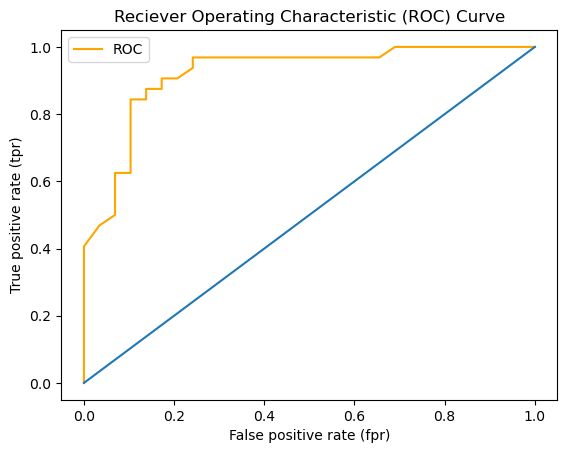

In [94]:
# Create a function for ROC curves diagram
import matplotlib.pyplot as plt

def plot_roc_curve(fpr, tpr):
    """
    Plots a ROC curve given the false positive rate (fpr) and 
    true positive rate (tpr) of an estimator.
    """
    # Plot ROC curve
    plt.plot(fpr, tpr, color="orange", label="ROC")
    # Plot line with no predictive power (baseline)
    plt.plot([0, 1], [0, 1])

    # Customize the plot
    plt.xlabel("False positive rate (fpr)")
    plt.ylabel("True positive rate (tpr)")
    plt.title("Reciever Operating Characteristic (ROC) Curve")
    plt.legend()
    plt.show()

plot_roc_curve(fpr, tpr)

In [95]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_probs_positive)

0.9207974137931034

In [ ]:
# Plot perfect ROC curve and AUC score
fpr, tpr, thresolds = roc_curve (y_test, y_te